In [1]:
import pandas as pd
import numpy as np
from pyod.models.knn import KNN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json

In [2]:
# Načtení datasetu
df = pd.read_csv("../data/AirQualityUCI.csv", sep=';', decimal=',')

# Odstranění prázdných sloupců
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Odstranění prázdných řádků
df.dropna(how='all', inplace=True)

In [3]:
# Odstranění všech záznamů, které obsahují chybějící hodnoty (-200) v některém z atributů
cols_to_check = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
                 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
                 'T', 'RH', 'AH']

df1 = df[(df[cols_to_check] != -200).all(axis=1)]

In [4]:
df1.describe().round(2)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00,827.00
mean,2.35,1207.88,231.03,10.77,966.12,143.50,963.30,100.26,1600.62,1045.81,15.60,49.05,0.83
std,1.41,241.82,208.46,7.42,266.42,81.83,265.91,31.49,302.29,400.13,4.83,15.27,0.18
min,0.30,753.00,7.00,0.50,448.00,12.00,461.00,19.00,955.00,263.00,6.30,14.90,0.40
25%,1.30,1017.00,77.00,4.80,754.00,81.00,769.00,78.50,1369.50,760.00,11.90,36.70,0.72
50%,2.00,1172.00,157.00,9.10,944.00,128.00,920.00,99.00,1556.00,1009.00,15.00,49.60,0.82
75%,3.10,1380.00,318.50,14.80,1142.50,187.00,1131.00,122.00,1783.50,1320.00,18.30,60.55,0.93
max,8.10,2040.00,1189.00,39.20,1754.00,478.00,1935.00,196.00,2679.00,2359.00,30.00,83.20,1.49


In [5]:
# Výběr sloupců pro analýzu
selected_attributes = ['CO(GT)','NOx(GT)']

df_selected = df1[selected_attributes].copy()

### KNN

In [6]:
# Standardizace
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

# Uložení do DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=selected_attributes)

In [7]:
# Inicializace a natrénování modelu KNN
knn = KNN()
knn.fit(df_scaled)

# Získání binárních výsledků (0 = inlier, 1 = outlier)
labels = knn.labels_

# Získání skóre
scores = knn.decision_scores_

# Přidání výsledků do původního DataFrame
df_selected["knn_outlier"] = labels
df_selected["knn_score"] = scores

In [8]:
# Filtrování pouze outlierů dle KNN
outliers_knn = df_selected[df_selected["knn_outlier"] == 1]

# Uložení do CSV
outliers_knn.to_json("../outliers/export/outliers_knn.json", orient="records", indent=4)

In [9]:
# Kolik je outlierů (label 1)
n_outliers = df_selected["knn_outlier"].sum()
print(f"Počet outlierů detekovaných KNN: {n_outliers}")

Počet outlierů detekovaných KNN: 83


### Shewhart

In [10]:
# Vybrané atributy pro Shewharta
shewhart_cols = ['CO(GT)','NOx(GT)']

# Inicializace slovníků pro uložení hraničních hodnot
limits_std = {}
limits_mad = {}

# Kopie dat
df_shewhart = df_selected.copy()

In [ ]:
for col in shewhart_cols:
    values = df_shewhart[col]

    # Průměr + směrodatná odchylka
    mean = values.mean()
    std = values.std()
    limits_std[col] = {
        "center": mean,
        "ucl": mean + 3 * std,
        "lcl": mean - 3 * std
    }

    # Medián + MAD
    median = values.median()
    mad = np.median(np.abs(values - median))
    limits_mad[col] = {
        "center": median,
        "ucl": median + 3 * mad,
        "lcl": median - 3 * mad
    }

In [12]:
with open("../outliers/export/shewhart_limits_std.json", "w") as f:
    json.dump(limits_std, f, indent=4)

with open("../outliers/export/shewhart_limits_mad.json", "w") as f:
    json.dump(limits_mad, f, indent=4)

In [13]:
# Inicializace masek pro oba přístupy
outliers_std_mask = pd.Series(False, index=df_shewhart.index)
outliers_mad_mask = pd.Series(False, index=df_shewhart.index)

for col in shewhart_cols:
    # Hranice ze slovníků
    ucl_std = limits_std[col]["ucl"]
    lcl_std = limits_std[col]["lcl"]
    ucl_mad = limits_mad[col]["ucl"]
    lcl_mad = limits_mad[col]["lcl"]

    # Detekce – kde hodnoty překračují meze
    outliers_std_mask |= (df_shewhart[col] > ucl_std) | (df_shewhart[col] < lcl_std)
    outliers_mad_mask |= (df_shewhart[col] > ucl_mad) | (df_shewhart[col] < lcl_mad)

# Přidání sloupců do DataFrame
df_shewhart["shewhart_outlier_std"] = outliers_std_mask
df_shewhart["shewhart_outlier_mad"] = outliers_mad_mask

In [14]:
# Průměr + std
outliers_std = df_shewhart[df_shewhart["shewhart_outlier_std"] == True]
outliers_std[shewhart_cols].to_json("../outliers/export/shewhart_outliers_std.json", orient="records", indent=4)

# Medián + MAD
outliers_mad = df_shewhart[df_shewhart["shewhart_outlier_mad"] == True]
outliers_mad[shewhart_cols].to_json("../outliers/export/shewhart_outliers_mad.json", orient="records", indent=4)

In [15]:
n_std_outliers = df_shewhart["shewhart_outlier_std"].sum()
print(f"Počet outlierů podle průměru a směrodatné odchylky: {n_std_outliers}")
n_mad_outliers = df_shewhart["shewhart_outlier_mad"].sum()
print(f"Počet outlierů podle mediánu a MAD: {n_mad_outliers}")

Počet outlierů podle průměru a směrodatné odchylky: 12
Počet outlierů podle mediánu a MAD: 75


#### Porovnání KNN a MAD

In [16]:
# Získání masek
knn_mask = df_shewhart["knn_outlier"] == 1
mad_mask = df_shewhart["shewhart_outlier_mad"] == True

# Společné outliery
both_outliers = df_shewhart[knn_mask & mad_mask]
only_knn = df_shewhart[knn_mask & ~mad_mask]
only_mad = df_shewhart[~knn_mask & mad_mask]

# Výpis počtů
print(f"Outliery podle KNN: {knn_mask.sum()}")
print(f"Outliery podle MAD: {mad_mask.sum()}")
print(f"Společné outliery (KNN ∩ MAD): {len(both_outliers)}")
print(f"Pouze KNN: {len(only_knn)}")
print(f"Pouze MAD: {len(only_mad)}")


Outliery podle KNN: 83
Outliery podle MAD: 75
Společné outliery (KNN ∩ MAD): 62
Pouze KNN: 21
Pouze MAD: 13


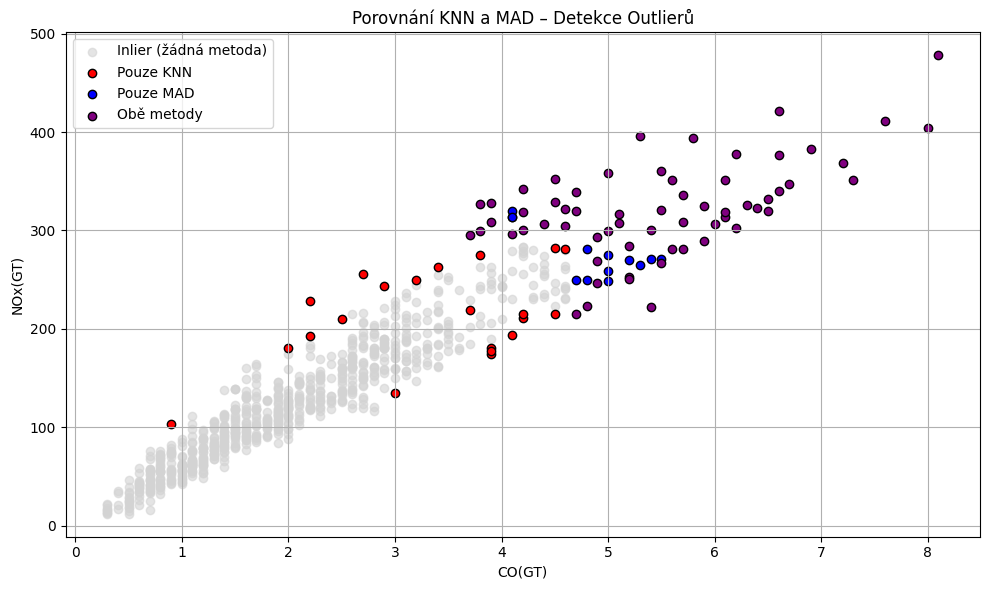

In [17]:
# Dvě proměnné pro zobrazení
x_attr = "CO(GT)"
y_attr = "NOx(GT)"

# Logické masky
mask_knn = df_shewhart["knn_outlier"] == 1
mask_mad = df_shewhart["shewhart_outlier_mad"] == True

# Kategorizace
inliers = df_shewhart[~mask_knn & ~mask_mad]
only_knn = df_shewhart[mask_knn & ~mask_mad]
only_mad = df_shewhart[~mask_knn & mask_mad]
both = df_shewhart[mask_knn & mask_mad]

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(inliers[x_attr], inliers[y_attr], color='lightgray', label='Inlier (žádná metoda)', alpha=0.6)
plt.scatter(only_knn[x_attr], only_knn[y_attr], color='red', label='Pouze KNN', edgecolors='k')
plt.scatter(only_mad[x_attr], only_mad[y_attr], color='blue', label='Pouze MAD', edgecolors='k')
plt.scatter(both[x_attr], both[y_attr], color='purple', label='Obě metody', edgecolors='k')

plt.xlabel(x_attr)
plt.ylabel(y_attr)
plt.title("Porovnání KNN a MAD – Detekce Outlierů")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
